# F11: Vektorfelt, gradient, divergens og rotasjon (curl)

I denne notatboken ser vi hvordan vi kan bruke Python (Numpy, Matplotlib og Sympy) til å

1. plotte **vektorfelt**,
2. regne ut og visualisere **gradienten** $\nabla f$ til en funksjon $f$, sammen med **nivåkurvene** til $f$,
3. regne ut og visualisere **divergens**,
4. regne ut og visualisere **curl** (rotasjon),

og til slutt se hvordan divergens og curl fanger opp to forskjellige, uavhengige sider av en strømning.

Strømlinjer/baner, potensialfunksjoner og konservative vektorfelt -- som bygger videre på dette -- finner du i `F12_Potensialfunksjoner_Stromlinjer_Konservative.ipynb`.

Dette bygger på `operators_sympy.ipynb` (symbolsk div/grad/curl med Sympy) og `Vektorfelt Visualisering.ipynb` / `DivTeoremet_Plot.ipynb` (visualisering av vektorfelt og baner).

In [1]:
import numpy as np                      # numerisk regning (arrays, rutenett, ...)
import matplotlib.pyplot as plt         # plotting (quiver, streamplot, contour, ...)
import sympy as sp                      # symbolsk regning (derivasjon, forenkling, ...)
import sympy.vector as vect             # symbolsk div/grad/curl med "ordentlige" vektoroperatorer
from scipy.integrate import solve_ivp   # numerisk løsning av differensiallikninger (baner/strømlinjer)

%matplotlib inline
plt.rcParams["figure.figsize"] = (6, 6)  # default figurstørrelse for resten av notatboken

## 1. Vektorfelt: hvordan plotte dem

Et vektorfelt $\vec F(x,y)=(u(x,y),v(x,y))$ kan visualiseres med `plt.quiver` (piler) eller `plt.streamplot` (sammenhengende strømlinjer). Vi starter med et enkelt eksempel, som i `Vektorfelt Visualisering.ipynb`:

$$\vec F(x,y) = 2y\,\vec\imath + x\,\vec\jmath.$$

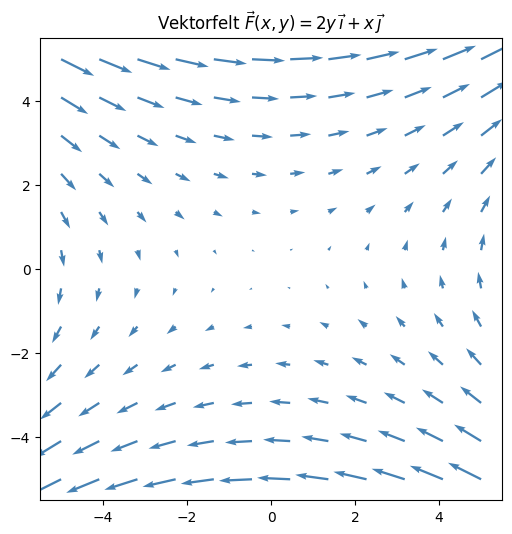

In [2]:
def F1(x, y):
    return 2*y, x   # F(x,y) = (2y, x): første tall er x-komponenten, andre er y-komponenten

# Lag et rutenett av punkter (x,y) i planet der vi vil evaluere feltet
xv = np.linspace(-5, 5, 12)
yv = np.linspace(-5, 5, 12)
X, Y = np.meshgrid(xv, yv)   # X og Y er 2D-arrays med alle kombinasjoner av x- og y-verdier
U, V = F1(X, Y)              # regn ut feltets to komponenter i hvert punkt i rutenettet

fig, ax = plt.subplots()
ax.quiver(X, Y, U, V, color='steelblue')   # quiver tegner én pil (U,V) i hvert punkt (X,Y)
ax.set_title(r"Vektorfelt $\vec F(x,y)=2y\,\vec\imath + x\,\vec\jmath$")
ax.set_aspect('equal')   # samme skala på x- og y-aksen, så pilene ikke blir skjeve
plt.show()

`streamplot` gir et glattere bilde av strømningen, siden strømlinjene alltid er tangente til feltet:

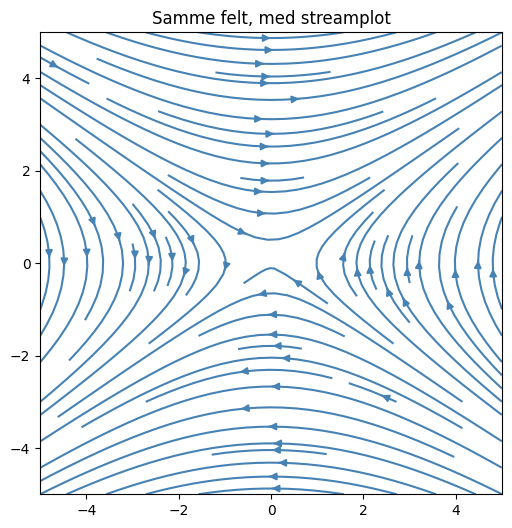

In [3]:
# Samme felt som over, men nå med et mye finere rutenett -- streamplot trenger dette
# for å kunne tegne glatte, sammenhengende strømlinjer i stedet for enkeltpiler
xv = np.linspace(-5, 5, 200)
yv = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(xv, yv)
U, V = F1(X, Y)

fig, ax = plt.subplots()
# streamplot tegner kurver som er tangente til feltet i ethvert punkt de går gjennom;
# density styrer hvor tett strømlinjene ligger
ax.streamplot(xv, yv, U, V, density=1.2, color='steelblue')
ax.set_title("Samme felt, med streamplot")
ax.set_aspect('equal')
plt.show()

Vektorfelt i 3D plottes på samme måte, med `ax.quiver` for en 3D-akse:

$$\vec{F}(x, y, z) = \sin(\pi x)\cos(\pi y) \cos(\pi z)\,\vec{i} - \cos(\pi x)\sin(\pi y)\cos(\pi z)\,\vec{j} + \cos(\pi x) \cos(\pi y) \sin(\pi z)\,\vec{k}$$

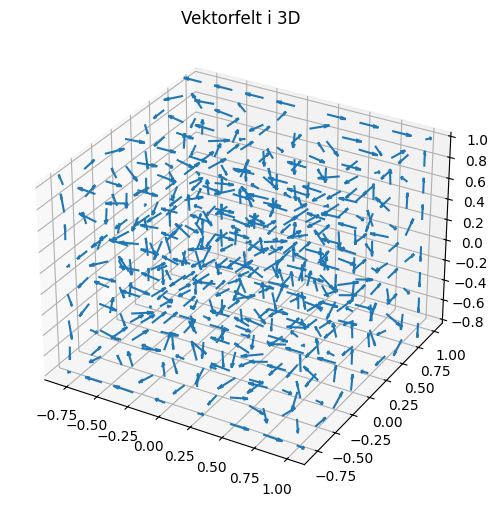

In [4]:
ax = plt.figure().add_subplot(projection='3d')   # 3D-akse i stedet for en vanlig 2D-akse

# Lag et 3D-rutenett av punkter (x,y,z) -- samme idé som meshgrid i 2D, bare én dimensjon til
x, y, z = np.meshgrid(np.linspace(-0.8, 1, 8),
                       np.linspace(-0.8, 1, 8),
                       np.linspace(-0.8, 1, 8))

# Feltets tre komponenter (u,v,w), evaluert i hvert punkt i rutenettet
u = np.sin(np.pi * x) * np.cos(np.pi * y) * np.cos(np.pi * z)
v = -np.cos(np.pi * x) * np.sin(np.pi * y) * np.cos(np.pi * z)
w = np.cos(np.pi * x) * np.cos(np.pi * y) * np.sin(np.pi * z)

# normalize=True gjør alle pilene like lange (bare retningen vises); length skalerer dem
ax.quiver(x, y, z, u, v, w, length=0.15, normalize=True)
ax.set_title("Vektorfelt i 3D")
plt.show()

**Oppgave (løses i forelesningen):** Lag et quiver-plott av $\vec F(x,y)=(-y,x)$ og av $\vec F(x,y)=(x,y)$. Hva slags strømning ser du i hvert tilfelle (rotasjon? kilde? sluk?) -- vi kommer tilbake til akkurat disse to feltene flere ganger i resten av notatboken.

In [5]:
# Skriv koden her


## 2. Gradienten $\nabla f$ og nivåkurver

For en skalarfunksjon $f(x,y)$ er gradienten vektorfeltet

$$\nabla f(x,y) = \left(\frac{\partial f}{\partial x},\ \frac{\partial f}{\partial y}\right).$$

Gradienten peker i den retningen $f$ *vokser raskest*, og lengden $|\nabla f|$ er hvor raskt $f$ vokser i den retningen. En **nivåkurve** til $f$ for et gitt nivå $k$ er mengden $\{(x,y): f(x,y)=k\}$.

Vi starter med å regne gradienten ut symbolsk med Sympy.

In [6]:
x, y = sp.symbols('x y')     # definer x og y som symbolske variable (ikke tall)
f_expr = x**2 - y**2         # funksjonen vi skal derivere

# Gradienten er ganske enkelt de to partiellderiverte, samlet i en liste/vektor
grad_f_expr = [sp.diff(f_expr, x), sp.diff(f_expr, y)]
print("f(x,y)  =", f_expr)
print("grad f  =", grad_f_expr)

f(x,y)  = x**2 - y**2
grad f  = [2*x, -2*y]


Vi kan gjøre det samme med `sympy.vector`, akkurat som i `operators_sympy.ipynb`:

In [7]:
R = vect.CoordSys3D('R')    # et koordinatsystem med "innebygde" symboler R.x, R.y, R.z
f_R = R.x**2 - R.y**2        # samme funksjon som over, bare uttrykt med sympy.vector-symbolene

Nabla = vect.Del()           # Del() representerer selve nabla-operatoren ∇
print(Nabla(f_R).doit())     # ∇f -- doit() tvinger Sympy til faktisk å regne ut derivasjonen

2*R.x*R.i + (-2*R.y)*R.j


Nå lager vi numeriske funksjoner ut fra de symbolske uttrykkene (med `sp.lambdify`) og plotter gradientfeltet sammen med nivåkurvene til $f$.

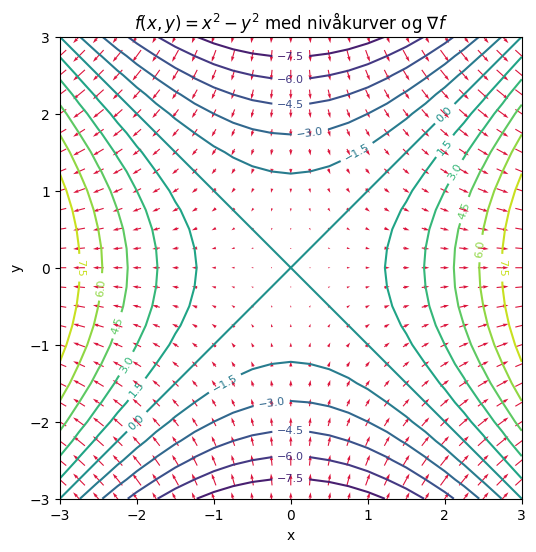

In [8]:
# lambdify gjør et symbolsk Sympy-uttrykk om til en vanlig, rask Python-funksjon som
# kan ta numpy-arrays som input direkte (det er det 'numpy' betyr her)
f_num = sp.lambdify((x, y), f_expr, 'numpy')
grad_num = sp.lambdify((x, y), grad_f_expr, 'numpy')

xv = np.linspace(-3, 3, 25)
yv = np.linspace(-3, 3, 25)
X, Y = np.meshgrid(xv, yv)

Z = f_num(X, Y)        # funksjonsverdiene f(x,y) i hele rutenettet -- brukes til nivåkurvene
U, V = grad_num(X, Y)  # gradienten (U,V) i hvert punkt -- brukes til pilene

fig, ax = plt.subplots()
kontur = ax.contour(X, Y, Z, levels=14, cmap='viridis')   # nivåkurvene til f
ax.clabel(kontur, inline=True, fontsize=8)                 # skriv f-verdien på hver nivåkurve
ax.quiver(X, Y, U, V, color='crimson', pivot='mid')        # pilene: gradientfeltet ∇f

ax.set_title(r"$f(x,y)=x^2-y^2$ med nivåkurver og $\nabla f$")
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.show()

**Bemerkning:** legg merke til at $\nabla f$ alltid står *ortogonalt* på nivåkurvene, og peker i retningen $f$ øker (bort fra sadelpunktet langs $x$-aksen, mot det langs $y$-aksen).

Et annet, kanskje mer kjent, eksempel er $f(x,y)=x^2+y^2$, der nivåkurvene er sirkler med radius $\sqrt{k}$:

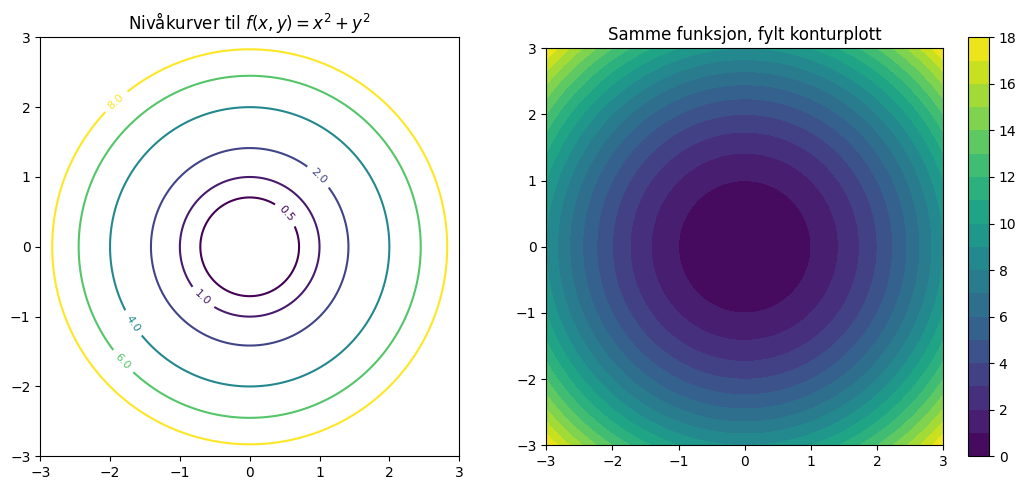

In [9]:
def f2(x, y):
    return x**2 + y**2   # en vanlig Python/numpy-funksjon (ikke symbolsk denne gangen)

xv = np.linspace(-3, 3, 200)
yv = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(xv, yv)
Z = f2(X, Y)

nivaer = [0.5, 1, 2, 4, 6, 8]   # velg selv hvilke f-verdier vi vil ha nivåkurver for

fig, axs = plt.subplots(1, 2, figsize=(11, 5))   # to plott side ved side

# Venstre: contour tegner bare selve nivåkurvene (linjene der f(x,y) = konstant)
k1 = axs[0].contour(X, Y, Z, levels=nivaer, cmap='viridis')
axs[0].clabel(k1, inline=True, fontsize=8)
axs[0].set_title(r"Nivåkurver til $f(x,y)=x^2+y^2$")
axs[0].set_aspect('equal')

# Høyre: contourf fyller mellomrommet mellom nivåkurvene med farge
c2 = axs[1].contourf(X, Y, Z, levels=20, cmap='viridis')
fig.colorbar(c2, ax=axs[1])
axs[1].set_title("Samme funksjon, fylt konturplott")
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

**Oppgave (løses i forelesningen):** Bytt ut `f_expr` med for eksempel $f(x,y)=\sin(x)\cos(y)$ og kjør cellene på nytt. Hvordan endrer nivåkurvene og gradientfeltet seg? Er $\nabla f$ fortsatt ortogonal på nivåkurvene?

In [10]:
# Skriv koden her


## 3. Divergens

For et vektorfelt $\vec F(x,y)=(u(x,y),v(x,y))$ er divergensen det **skalare** uttrykket

$$\operatorname{div}\vec F = \nabla\cdot\vec F = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y}$$

(i 3D med et $+\,\partial w/\partial z$-ledd i tillegg). Divergensen måler hvor mye feltet "sprer seg ut" (kilde, $\operatorname{div}\vec F>0$) eller "strømmer inn" (sluk, $\operatorname{div}\vec F<0$) i et punkt.

Vi regner den ut symbolsk med `sympy.vector`, som i `operators_sympy.ipynb`:

In [11]:
C = vect.CoordSys3D('C')            # nytt koordinatsystem for sympy.vector
felt = C.x*C.i + C.y*C.j            # feltet F(x,y) = (x, y), skrevet med enhetsvektorene i, j

print("div F =", vect.divergence(felt))   # vect.divergence regner ut ∇·F direkte

div F = 2


### To eksempler: har et sentralsymmetrisk felt divergens, eller ikke?

Vi sammenligner to felt som begge peker radielt ut fra origo:

$$\vec F_1(x,y) = (x,y) \qquad\text{og}\qquad \vec F_2(x,y) = \frac{(x,y)}{x^2+y^2}.$$

$\vec F_2$ er nettopp det todimensjonale gravitasjons-/Coulomb-feltet (jamfør **Eksempel 2.7** i kompendiet, tilfellet $d=2,\,n=1$ der): et sentralsymmetrisk felt $C\hat{\vec r}/r^n$ har generelt divergens ulik null, men for nøyaktig denne potensen ($n=d-1$) forsvinner divergensen bort fra origo. La oss sjekke det symbolsk og visuelt.

In [12]:
u1_expr, v1_expr = x, y                                        # F1 = (x, y)
u2_expr, v2_expr = x/(x**2 + y**2), y/(x**2 + y**2)             # F2 = (x, y)/(x^2+y^2)

# div F = ∂u/∂x + ∂v/∂y -- to partiellderiverte, lagt sammen
div1 = sp.diff(u1_expr, x) + sp.diff(v1_expr, y)
div2_ = sp.simplify(sp.diff(u2_expr, x) + sp.diff(v2_expr, y))   # simplify rydder opp i uttrykket
print("div F1 = div (x, y)              =", div1)
print("div F2 = div (x, y)/(x^2+y^2)     =", div2_)

div F1 = div (x, y)              = 2
div F2 = div (x, y)/(x^2+y^2)     = 0


<lambdifygenerated-5>:2: RuntimeWarning: invalid value encountered in divide
  return x/(x**2 + y**2)
<lambdifygenerated-6>:2: RuntimeWarning: invalid value encountered in divide
  return y/(x**2 + y**2)


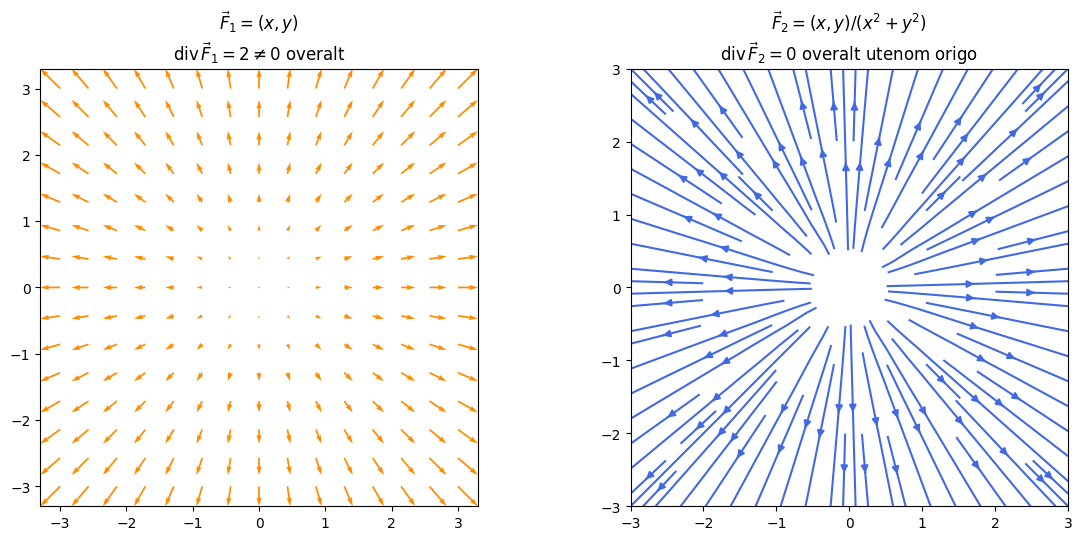

In [13]:
# Gjør de symbolske feltene om til numeriske funksjoner, og plott dem side ved side
u1_num = sp.lambdify((x, y), u1_expr, 'numpy')
v1_num = sp.lambdify((x, y), v1_expr, 'numpy')
u2_num = sp.lambdify((x, y), u2_expr, 'numpy')
v2_num = sp.lambdify((x, y), v2_expr, 'numpy')

xv = np.linspace(-3, 3, 15)
yv = np.linspace(-3, 3, 15)
X, Y = np.meshgrid(xv, yv)

fig, axs = plt.subplots(1, 2, figsize=(12, 5.5))   # ett plott per felt

axs[0].quiver(X, Y, u1_num(X, Y), v1_num(X, Y), color='darkorange')
axs[0].set_title(r"$\vec F_1=(x,y)$" + "\n" + r"$\operatorname{div}\vec F_1=2\neq0$ overalt")
axs[0].set_aspect('equal')

# streamplot her, siden feltet "blåser opp" mot uendelig nær origo -- quiver ville gitt
# uleselig lange piler der
axs[1].streamplot(xv, yv, u2_num(X, Y), v2_num(X, Y), color='royalblue', density=1.2)
axs[1].set_title(r"$\vec F_2=(x,y)/(x^2+y^2)$" + "\n" + r"$\operatorname{div}\vec F_2=0$ overalt utenom origo")
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

Legg merke til at $\vec F_2$ visuelt ser ut som et helt vanlig "kildefelt" -- pilene peker jo tydelig radielt utover -- men divergensen er likevel null i ethvert punkt utenom origo selv (der feltet ikke er definert). Dette er altså *ikke* en generell egenskap ved sentralsymmetriske felt: bytter vi eksponenten (for eksempel til $\vec F=(x,y)/(x^2+y^2)^{1.5}$, altså $C\hat{\vec r}/r^2$ i $d=2$ dimensjoner), får vi divergens ulik null igjen. Det er den helt spesifikke potensen $n=d-1$ (som gir nøyaktig Coulombs lov/Newtons gravitasjonslov) som gjør at divergensen forsvinner -- se **Eksempel 2.7** i kompendiet for den generelle utregningen i $d$ dimensjoner.

Divergensen kan også variere fra punkt til punkt, og da er det ofte fint å visualisere den som et fargekart med feltet lagt over.

div (x^2, y^2) = 2*x + 2*y


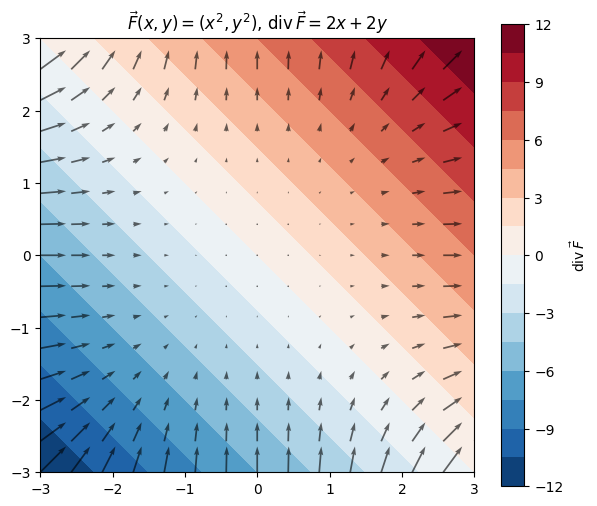

In [14]:
u3_expr, v3_expr = x**2, y**2
div3_expr = sp.diff(u3_expr, x) + sp.diff(v3_expr, y)
print("div (x^2, y^2) =", div3_expr)

u3_num = sp.lambdify((x, y), u3_expr, 'numpy')
v3_num = sp.lambdify((x, y), v3_expr, 'numpy')
div3_num = sp.lambdify((x, y), div3_expr, 'numpy')

# Ett fint rutenett til selve fargekartet (skal se glatt ut) ...
xv = np.linspace(-3, 3, 200)
yv = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(xv, yv)
Zdiv = div3_num(X, Y)

# ... og ett grovere rutenett bare til pilene (så de ikke blir for tette til å se)
xv2 = np.linspace(-3, 3, 15)
yv2 = np.linspace(-3, 3, 15)
X2, Y2 = np.meshgrid(xv2, yv2)
U2, V2 = u3_num(X2, Y2), v3_num(X2, Y2)

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(X, Y, Zdiv, levels=20, cmap='RdBu_r')   # fargekart: rødt/blått = positiv/negativ divergens
fig.colorbar(c, ax=ax, label=r'$\operatorname{div}\vec F$')
ax.quiver(X2, Y2, U2, V2, color='black', alpha=0.6)      # feltet selv, lagt over fargekartet
ax.set_title(r"$\vec F(x,y)=(x^2,y^2)$, $\operatorname{div}\vec F=2x+2y$")
ax.set_aspect('equal')
plt.show()

**Oppgave (løses i forelesningen):** Finn et vektorfelt med divergens lik null overalt (et *divergensfritt* eller *inkompressibelt* felt), og lag et fargekart som bekrefter det (fargen bør være helt jevn over hele planet).

In [15]:
# Skriv koden her


## 4. Curl (rotasjon)

I 3D er curl til et vektorfelt $\vec F=(u,v,w)$ selv en **vektor**,

$$\operatorname{curl}\vec F = \nabla\times\vec F = \left(\frac{\partial w}{\partial y}-\frac{\partial v}{\partial z},\ \frac{\partial u}{\partial z}-\frac{\partial w}{\partial x},\ \frac{\partial v}{\partial x}-\frac{\partial u}{\partial y}\right),$$

og den måler hvor mye feltet "roterer" lokalt (retningen gis av høyrehåndsregelen). I 2D er det bare $z$-komponenten som er forskjellig fra null, og vi kaller ofte tallet den **skalare curlen**:

$$\operatorname{curl}\vec F = \frac{\partial v}{\partial x}-\frac{\partial u}{\partial y}.$$

Vi regner ut curl symbolsk med `sympy.vector`, som i `operators_sympy.ipynb`:

In [16]:
felt3 = C.x*C.y*C.z*C.i     # et 3D-felt F = (xyz, 0, 0) -- bare x-komponent, resten null
print("curl F =", vect.curl(felt3))   # vect.curl regner ut ∇×F direkte

curl F = C.x*C.y*C.j + (-C.x*C.z)*C.k


### To eksempler: har et sentralsymmetrisk rotasjonsfelt curl, eller ikke?

På samme måte som for divergens sammenligner vi et rent rotasjonsfelt med sin sentralsymmetriske "utvannede" versjon:

$$\vec F_3(x,y) = (y,-x) \qquad\text{og}\qquad \vec F_4(x,y) = \frac{(y,-x)}{x^2+y^2}.$$

In [17]:
u3c_expr, v3c_expr = y, -x                                       # F3 = (y, -x)
u4c_expr, v4c_expr = y/(x**2 + y**2), -x/(x**2 + y**2)            # F4 = (y, -x)/(x^2+y^2)

# curl F (2D, skalar) = ∂v/∂x - ∂u/∂y
curl3_ = sp.diff(v3c_expr, x) - sp.diff(u3c_expr, y)
curl4_ = sp.simplify(sp.diff(v4c_expr, x) - sp.diff(u4c_expr, y))
print("curl F3 = curl (y,-x)             =", curl3_)
print("curl F4 = curl (y,-x)/(x^2+y^2)   =", curl4_)

curl F3 = curl (y,-x)             = -2
curl F4 = curl (y,-x)/(x^2+y^2)   = 0


<lambdifygenerated-12>:2: RuntimeWarning: invalid value encountered in divide
  return y/(x**2 + y**2)
<lambdifygenerated-13>:2: RuntimeWarning: invalid value encountered in divide
  return -x/(x**2 + y**2)


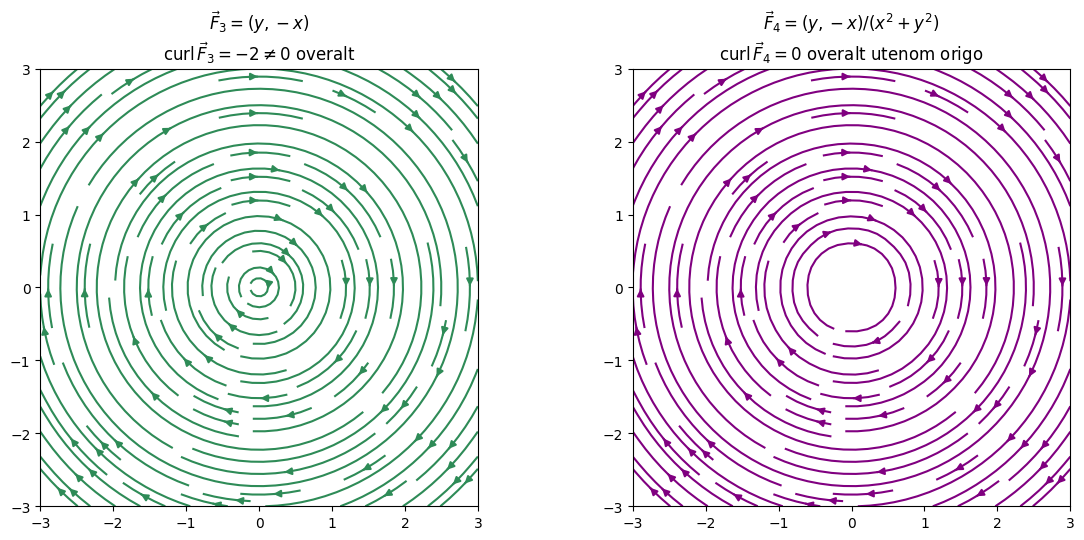

In [18]:
# Gjør de symbolske feltene om til numeriske funksjoner, og plott dem side ved side
u3c_num = sp.lambdify((x, y), u3c_expr, 'numpy')
v3c_num = sp.lambdify((x, y), v3c_expr, 'numpy')
u4c_num = sp.lambdify((x, y), u4c_expr, 'numpy')
v4c_num = sp.lambdify((x, y), v4c_expr, 'numpy')

xv = np.linspace(-3, 3, 15)
yv = np.linspace(-3, 3, 15)
X, Y = np.meshgrid(xv, yv)

fig, axs = plt.subplots(1, 2, figsize=(12, 5.5))   # ett plott per felt

axs[0].streamplot(xv, yv, u3c_num(X, Y), v3c_num(X, Y), color='seagreen', density=1.2)
axs[0].set_title(r"$\vec F_3=(y,-x)$" + "\n" + r"$\operatorname{curl}\vec F_3=-2\neq0$ overalt")
axs[0].set_aspect('equal')

axs[1].streamplot(xv, yv, u4c_num(X, Y), v4c_num(X, Y), color='purple', density=1.2)
axs[1].set_title(r"$\vec F_4=(y,-x)/(x^2+y^2)$" + "\n" + r"$\operatorname{curl}\vec F_4=0$ overalt utenom origo")
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

Igjen ser $\vec F_4$ visuelt ut som en helt vanlig virvel -- strømlinjene går tydelig i sirkler rundt origo -- men curl er likevel null i ethvert punkt utenom origo. Dette er *nøyaktig* feltet fra **Eksempel 2.8** i kompendiet, der akkurat dette poenget diskuteres: ordet "irrotasjonell" kan skape forvirring, siden feltet jo tydelig ser ut til å rotere. Løsningen på gåten er at all "rotasjonen" er konsentrert i origo selv -- som ikke er med i definisjonsmengden $\R^2\setminus\{\vec 0\}$.

Legg merke til den fine parallellen til divergens-eksemplet over: i begge tilfeller gir den generelle, "rå" versjonen av feltet ($\vec F_1$, $\vec F_3$) en konstant, ulik-null verdi av operatoren, mens den spesielle sentralsymmetriske potensen ($\vec F_2$, $\vec F_4$) gir null -- bort sett fra i et enkelt, unntatt punkt.

**Oppgave (løses i forelesningen):** Finn et vektorfelt med curl lik null overalt (et *curl-fritt* eller *irrotasjonelt* felt -- for eksempel et gradientfelt!), og bekreft det symbolsk med Sympy.

In [19]:
# Skriv koden her


## 5. Divergens og curl: to "ortogonale" moter i en strømning

Divergens og curl fanger opp to helt forskjellige egenskaper ved et vektorfelt:

* $\operatorname{div}\vec F$ måler **ren utvidelse/sammentrekning** (en kilde eller et sluk, uten rotasjon).
* $\operatorname{curl}\vec F$ måler **ren rotasjon** (som en stiv skive, uten utvidelse).

Disse to modene er *uavhengige*: et rent kildefelt har curl $=0$, og et rent rotasjonsfelt har div $=0$. Det betyr at vi -- i alle fall lokalt, for lineære felt -- kan bygge en generell strømning ved å **legge sammen** en ren kilde/sluk-del og en ren rotasjonsdel.

Som eksempel ser vi på "spiralfeltet"

$$\vec F(x,y) = (x-y,\ x+y) \;=\; \underbrace{(x,y)}_{\vec F_{\mathrm{div}}} \;+\; \underbrace{(-y,x)}_{\vec F_{\mathrm{curl}}}.$$

In [20]:
Fdiv_u, Fdiv_v = x, y      # den rene "kilde/sluk"-delen
Fcurl_u, Fcurl_v = -y, x    # den rene "rotasjons"-delen
F_u, F_v = Fdiv_u + Fcurl_u, Fdiv_v + Fcurl_v   # summen av de to

# Regn ut div og curl for hvert av de tre feltene, og skriv dem ut side ved side
for navn, (uu, vv) in [("F_div  = (x, y)     ", (Fdiv_u, Fdiv_v)),
                        ("F_curl = (-y, x)    ", (Fcurl_u, Fcurl_v)),
                        ("F      = F_div+F_curl", (F_u, F_v))]:
    div_ = sp.diff(uu, x) + sp.diff(vv, y)
    curl_ = sp.diff(vv, x) - sp.diff(uu, y)
    print(f"{navn}:  F=({uu}, {vv}),  div F = {div_},  curl F = {curl_}")

F_div  = (x, y)     :  F=(x, y),  div F = 2,  curl F = 0
F_curl = (-y, x)    :  F=(-y, x),  div F = 0,  curl F = 2
F      = F_div+F_curl:  F=(x - y, x + y),  div F = 2,  curl F = 2


Legg merke til: `F_div` har curl $=0$ og `F_curl` har div $=0$ -- og for summen legger både divergensen og curlen seg helt enkelt sammen. Vi plotter de tre feltene ved siden av hverandre, med noen baner (`solve_ivp`) lagt over, for å se hvordan strømningen faktisk beveger seg:

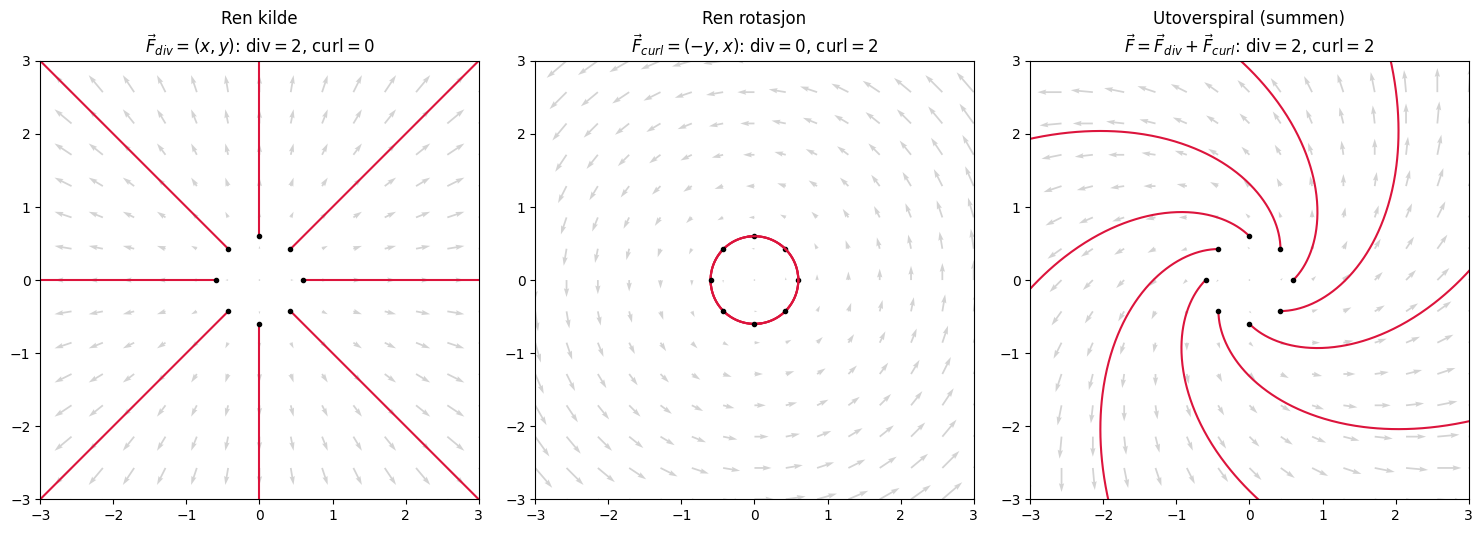

In [21]:
def lag_bane_figur(ax, u_func, v_func, tittel, T=2.5):
    # Tegner feltet (u_func, v_func) som piler, og legger noen baner (løst
    # numerisk med solve_ivp) over -- baner som starter i 8 punkter på en liten
    # sirkel med radius r0 rundt origo, og følges i tiden T.
    xv = np.linspace(-3, 3, 15)
    yv = np.linspace(-3, 3, 15)
    X, Y = np.meshgrid(xv, yv)
    U, V = u_func(X, Y), v_func(X, Y)
    ax.quiver(X, Y, U, V, color='lightgray')   # feltet selv, i lys grå bakgrunn

    def rhs(t, z):
        # høyresiden i banelikningen gamma'(t) = F(gamma(t)); z = (x, y) er posisjonen
        xx, yy = z
        return [u_func(xx, yy), v_func(xx, yy)]

    theta = np.linspace(0, 2*np.pi, 8, endpoint=False)   # 8 startpunkter, jevnt fordelt på en sirkel
    r0 = 0.6
    t_eval = np.linspace(0, T, 300)
    for th in theta:
        z0 = [r0*np.cos(th), r0*np.sin(th)]                    # startpunkt for denne banen
        sol = solve_ivp(rhs, (0, T), z0, t_eval=t_eval)         # løs banelikningen numerisk
        ax.plot(sol.y[0], sol.y[1], color='crimson')            # tegn selve banen
        ax.plot(z0[0], z0[1], 'o', color='black', ms=3)         # marker startpunktet

    ax.set_title(tittel)
    ax.set_aspect('equal')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
lag_bane_figur(axs[0], lambda x, y: x, lambda x, y: y,
                "Ren kilde\n" + r"$\vec F_{div}=(x,y)$: div$=2$, curl$=0$")
lag_bane_figur(axs[1], lambda x, y: -y, lambda x, y: x,
                "Ren rotasjon\n" + r"$\vec F_{curl}=(-y,x)$: div$=0$, curl$=2$")
lag_bane_figur(axs[2], lambda x, y: x - y, lambda x, y: x + y,
                "Utoverspiral (summen)\n" + r"$\vec F=\vec F_{div}+\vec F_{curl}$: div$=2$, curl$=2$")

plt.tight_layout()
plt.show()

Legg merke til: banene i venstre bilde går rett utover (ren utvidelse), banene i det midterste bildet går i sirkler (ren rotasjon), og når vi legger feltene sammen får vi spiraler utover -- nøyaktig summen av de to bevegelsene. Det er selve poenget: **hvor mye feltet "sprer seg ut" (div) og hvor mye det "roterer" (curl) er to uavhengige tall som sammen beskriver hvordan (den lineære delen av) en strømning ser ut lokalt.**

**Bemerkning (for de som vil vite mer):** for et *generelt* lineært felt $\vec F(x,y)=A\begin{pmatrix}x\\y\end{pmatrix}$ finnes det egentlig et tredje bidrag i tillegg til kilde/sluk-delen og rotasjonsdelen: en **skjærdel** (shear), som verken endrer areal (div $=0$) eller roterer (curl $=0$), men som strekker feltet i én retning og klemmer det sammen i en annen. Divergens og curl fanger altså opp to av (i alt tre) uavhengige "retninger" i rommet av lineære felt -- de er ortogonale på hverandre i den forstand at en ren kilde/sluk-del alltid har curl $=0$ og en ren rotasjonsdel alltid har div $=0$, men de fanger ikke opp *alt*. I eksempelet vårt valgte vi feltet nettopp slik at skjærdelen ble null, for å isolere de to modene vi var ute etter.

## Oppsummering

1. Vektorfelt plottes med `quiver` (piler) eller `streamplot` (strømlinjer), i 2D så vel som 3D.
2. Gradienten $\nabla f=(f_x,f_y)$ peker i retningen $f$ vokser raskest, og står alltid ortogonalt på nivåkurvene til $f$; nivåkurver plottes med `contour`/`contourf`.
3. Divergens $\operatorname{div}\vec F=u_x+v_y$ måler ren utvidelse (kilde, $>0$) eller sammentrekning (sluk, $<0$). Et sentralsymmetrisk felt $C\hat{\vec r}/r^n$ har generelt divergens ulik null -- unntaket er nøyaktig $n=d-1$ (Coulombs lov/Newtons gravitasjonslov), der divergensen forsvinner bort fra origo (Eksempel 2.7 i kompendiet).
4. Curl $\operatorname{curl}\vec F=v_x-u_y$ (2D, skalar) måler ren rotasjon. Samme fenomen gjentar seg: $C(y,-x)/r^n$ har generelt curl ulik null, men for $n=d-1$ forsvinner curlen bort fra origo, selv om feltet visuelt ser ut til å "rotere" (Eksempel 2.8 i kompendiet).
5. Div og curl er to uavhengige ("ortogonale") mål på en strømning: et rent kildefelt har curl $=0$, og et rent rotasjonsfelt har div $=0$. Et generelt lineært felt kan skrives som summen av disse to modene, pluss en eventuell skjærdel som verken div eller curl fanger opp.

Neste steg -- strømlinjer/baner, potensialfunksjoner og konservative vektorfelt -- finner du i `F12_Potensialfunksjoner_Stromlinjer_Konservative.ipynb`.